In [1]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.vstack([
    np.random.normal(0, 1, (10, 2)),
    np.random.normal(5, 1, (10, 2)),
    np.random.normal(10, 1, (10, 2))
])

In agglomerative clustering we will considering all the points as indivisual clusters and then merge it one after the other based on the distance metrics. the squareform function will be creating a 2d matrix which will represent the distance from one point to everyother point

the notation followed by scipy is that if there are 30 pints in the sample the 31st point will be regarded as the first cluster.Hence the current_id will start from n (n_samples), the Z matrix which is given to the dendogram is of the format [Cluster_1_ID, Cluster_2_ID, Distance, Number_of_Original_Points]

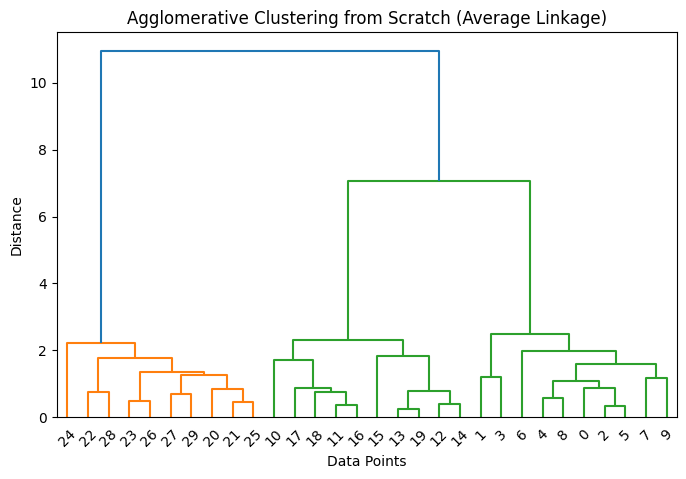

In [ ]:


def custom_agglomerative_clustering(X, method='average'):
    n_samples = len(X)
    
    dist_matrix = squareform(pdist(X))
    
    
    dist_dict = {}
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            dist_dict[(i, j)] = dist_matrix[i, j]
            
    
    active_clusters = list(range(n_samples))

    sizes = {i: 1 for i in range(n_samples)}
    
    Z = []                 
    current_id = n_samples
    
    
    for step in range(n_samples - 1):
        
        min_dist = np.inf
        closest_pair = None
        
        for (i, j), d in dist_dict.items():
            if i in active_clusters and j in active_clusters:
                if d < min_dist:
                    min_dist = d
                    closest_pair = (i, j)
        
        c1, c2 = closest_pair
        
        Z.append([c1, c2, min_dist, sizes[c1] + sizes[c2]])
        
        new_id = current_id
        current_id += 1
        sizes[new_id] = sizes[c1] + sizes[c2]
        
    
        for k in active_clusters:
            if k == c1 or k == c2:
                continue 
            
            d_k_c1 = dist_dict.get((min(k, c1), max(k, c1)))
            d_k_c2 = dist_dict.get((min(k, c2), max(k, c2)))
            
            
            if method == 'single':      
                d_new = min(d_k_c1, d_k_c2)
            elif method == 'complete': 
                d_new = max(d_k_c1, d_k_c2)
            elif method == 'average':  
                d_new = (sizes[c1] * d_k_c1 + sizes[c2] * d_k_c2) / (sizes[c1] + sizes[c2])
            
            
            dist_dict[(min(k, new_id), max(k, new_id))] = d_new
        
        active_clusters.remove(c1)
        active_clusters.remove(c2)
        active_clusters.append(new_id)
        
    return np.array(Z)

np.random.seed(42)
X = np.vstack([
    np.random.normal(0, 1, (10, 2)),
    np.random.normal(5, 1, (10, 2)),
    np.random.normal(10, 1, (10, 2))
])


Z_agg = custom_agglomerative_clustering(X, method='average')

plt.figure(figsize=(8, 5))
dendrogram(Z_agg)
plt.title("Agglomerative Clustering from Scratch (Average Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In divisive clustering the entire set of points is considered as 1 single cluster then its broken in multiple. In this code we have used k means to break it into 2 clusters and the 
""" if len(np.unique(labels)) == 1:  labels[0] = 1 - labels[0]"""  is given as a fail safe if the kmeans has considered overlapping points into the same cluster. In scipy dendogram it cant take a tree as an input sao we have to build an other function to join the dendogram again 

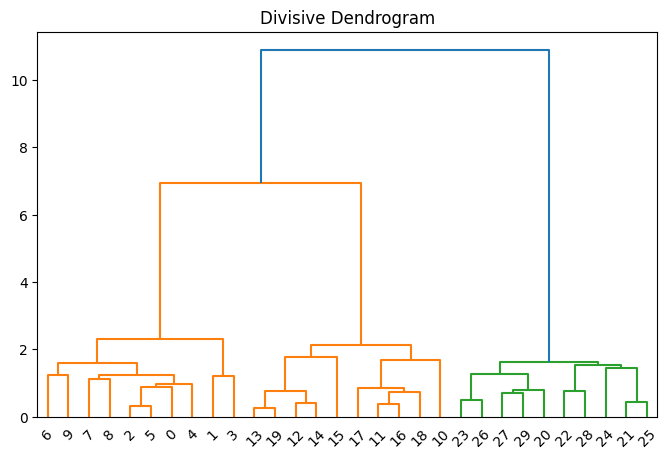

In [ ]:

from sklearn.cluster import KMeans


def divisiveclustering(X):             
    n_samples = len(X)                             
    current_id = n_samples                         
    
    def split(indices):                       
        nonlocal current_id                        
        if len(indices) == 1:                      
            return {'id': indices[0], 'indices': indices, 'left': None, 'right': None, 'dist': 0, 'size': 1}
        
        sub_X = X[indices]                         
        kmeans = KMeans(n_clusters=2, n_init=10, random_state=42).fit(sub_X)  
        labels = kmeans.labels_                    
        
        if len(np.unique(labels)) == 1:            
            labels[0] = 1 - labels[0]              
            
        left_idx = [indices[i] for i in range(len(indices)) if labels[i] == 0]  
        right_idx = [indices[i] for i in range(len(indices)) if labels[i] == 1] 
        
        
        dist = np.linalg.norm(kmeans.cluster_centers_[0] - kmeans.cluster_centers_[1]) 
    
        left_node = split(left_idx)           
        right_node = split(right_idx)         
        
        return {                                   
            'id': None, 'indices': indices, 'left': left_node, 'right': right_node, 
            'dist': dist, 'size': len(indices)
        }

    root = split(list(range(n_samples)))     
    Z = []                                         
    
    def build_linkage(node):                       
        nonlocal current_id                        
        if node['left'] is None and node['right'] is None:  
            return node['id'], 0                   
        
        left_id, left_dist = build_linkage(node['left'])   
        right_id, right_dist = build_linkage(node['right'])
        
        
        dist = max(node['dist'], left_dist + 0.1, right_dist + 0.1) 
        Z.append([left_id, right_id, dist, node['size']])  
        
        node['id'] = current_id                    
        current_id += 1                            
        
        return node['id'], dist                    

    build_linkage(root)                            
    return np.array(Z)                             

Z_top_down = divisiveclustering(X)     
plt.figure(figsize=(8, 5))                         
dendrogram(Z_top_down)                             
plt.title("Divisive Dendrogram")        
plt.show()                                         

mathematical shortcut used inside Agglomerative (Bottom-Up) Clustering.

Imagine you have 10,000 data points. You find the two closest points (let's call them Cluster A and Cluster B) and merge them into a new super-cluster: Cluster (A+B).

Now, you have to update your distance matrix. You need to figure out exactly how far away this new (A+B) cluster is from all the other 9,998 clusters (like Cluster C).

The Slow Way: Go back to the raw data, look at every single point inside (A+B), look at every point inside C, calculate all their distances, and find the average/min/max. If you do this for every step, your computer will crawl to a halt.

The Lance-Williams Way: Never look at the raw data again. If you already know how far A was from C, and how far B was from C, you can just plug those two numbers into a master formula to instantly find the distance from (A+B) to C

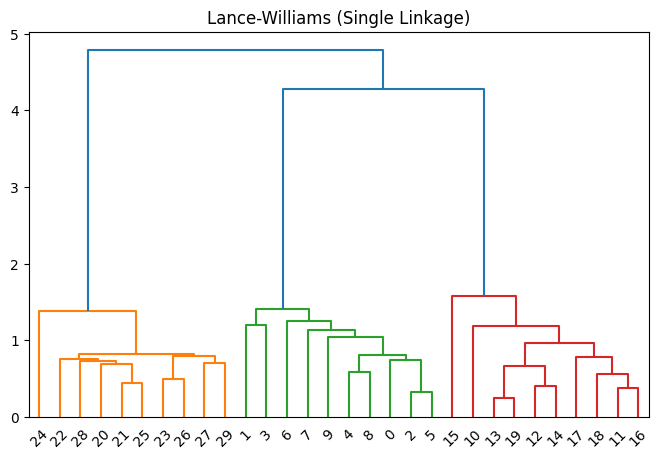

: 

In [ ]:

def lance_williams_dict(X):                        
    n = len(X)                                     
    dist_dict = {}                                 
    
    for i in range(n):                             
        for j in range(i+1, n):                    
            
            dist_dict[(i, j)] = np.linalg.norm(X[i] - X[j]) 
            
    sizes = {i: 1 for i in range(n)}               
    active_clusters = set(range(n))                
    Z = []                                         
    current_id = n                                     
    for step in range(n - 1):                      
        
        min_pair = min([p for p in dist_dict if p[0] in active_clusters and p[1] in active_clusters], key=dist_dict.get)
        i, j = min_pair                            
        min_dist = dist_dict[min_pair]             
        Z.append([i, j, min_dist, sizes[i] + sizes[j]]) 
        new_id = current_id                        
        current_id += 1                            
        sizes[new_id] = sizes[i] + sizes[j]       
        
        for k in active_clusters:                  
            if k == i or k == j: continue          
            
            d_ki = dist_dict.get((min(k, i), max(k, i))) 
            
            d_kj = dist_dict.get((min(k, j), max(k, j))) 
            
            
            d_new = 0.5 * d_ki + 0.5 * d_kj - 0.5 * abs(d_ki - d_kj)
                
            
            dist_dict[(min(k, new_id), max(k, new_id))] = d_new 
            
        active_clusters.remove(i)                  
        active_clusters.remove(j)                  
        active_clusters.add(new_id)                
    return np.array(Z)                             

Z_lw = lance_williams_dict(X)                      
plt.figure(figsize=(8, 5))                         
dendrogram(Z_lw)                                   
plt.title("Lance-Williams (Single Linkage)")       
plt.show()                                         